In [1]:
!pip uninstall torch torchvision torchaudio -y

!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

import torch
print(torch.cuda.is_available())           # Deve retornar: True
print(torch.cuda.get_device_name(0))       # Deve retornar: NVIDIA GeForce RTX 3050 Ti


Found existing installation: torch 2.5.1+cu121
Uninstalling torch-2.5.1+cu121:
  Successfully uninstalled torch-2.5.1+cu121
Found existing installation: torchvision 0.20.1+cu121
Uninstalling torchvision-0.20.1+cu121:
  Successfully uninstalled torchvision-0.20.1+cu121
Found existing installation: torchaudio 2.5.1+cu121
Uninstalling torchaudio-2.5.1+cu121:
  Successfully uninstalled torchaudio-2.5.1+cu121
Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download.pytorch.org/whl/cu121/torch-2.5.1%2Bcu121-cp312-cp312-win_amd64.whl (2449.3 MB)
  Using cached https://download.pytorch.org/whl/cu121/torchvision-0.20.1%2Bcu121-cp312-cp312-win_amd64.whl (6.1 MB)
  Using cached https://download.pytorch.org/whl/cu121/torchaudio-2.5.1%2Bcu121-cp312-cp312-win_amd64.whl (4.1 MB)
True
NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [2]:
# 📦 Instale antes se necessário:
# pip install ultralytics opencv-python matplotlib pandas pyyaml scikit-learn

import os
import yaml
import cv2
import torch
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
from ultralytics import YOLO
from sklearn.metrics import precision_score, recall_score, f1_score

# 📂 Dataset YAML com caminhos corretos
dataset_yaml = {
    "train": r"C:\\Users\\Jorge Cunha\\Desktop\\Python\\AI_Detection_Cars\\AAU2\\DetectObjects_JC\\dataset\\train\\images",
    "val": r"C:\\Users\\Jorge Cunha\\Desktop\\Python\\AI_Detection_Cars\\AAU2\\DetectObjects_JC\\dataset\\val\\images",
    "test": r"C:\\Users\\Jorge Cunha\\Desktop\\Python\\AI_Detection_Cars\\AAU2\\DetectObjects_JC\\dataset\\test\\images",
    "nc": 9,
    "names": [
        "Trafic Light Signal", "Stop Signal", "Speedlimit Signal", "Crosswalk Signal",
        "Crosswalk", "Pedestrian", "Bus", "Car", "Truck"
    ]
}

# 📝 Salva dataset.yaml
with open("dataset.yaml", "w") as f:
    yaml.dump(dataset_yaml, f)

# 🚀 Carregar modelo pré-treinado e treinar
model = YOLO("models/yolo11m.pt")
model.train(
    data="dataset.yaml",
    epochs=25,
    imgsz=640,
    batch=8,
    name="yolo11m_finetuned",
    workers=2,
    patience=5
)

# 📍 Caminho para o melhor modelo
best_model_path = "runs_first_yolo/detect/yolo11m_finetuned/weights/best.pt"

# 🔁 Recarrega o modelo com pesos treinados
model = YOLO(best_model_path)

# 📊 Avaliação no conjunto de validação
results = model.val(data="dataset.yaml", split="val", save_json=True)

# 🔎 Testar previsões manualmente
val_dir = dataset_yaml["val"]
image_paths = sorted([
    os.path.join(val_dir, f) for f in os.listdir(val_dir)
    if f.endswith((".jpg", ".png", ".jpeg"))
])

# 📌 Visualização de Previsões
def visualize_prediction(image_path, model, class_names, conf_thresh=0.4):
    image = cv2.imread(image_path)
    result = model(image_path)[0]

    for box, score, label in zip(result.boxes.xyxy, result.boxes.conf, result.boxes.cls):
        if score < conf_thresh:
            continue
        x1, y1, x2, y2 = map(int, box.tolist())
        class_id = int(label)
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(image, f"{class_names[class_id]} {score:.2f}", (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

# 🧪 Testar algumas imagens
for img in image_paths[:10]:
    print(f"🖼️ Imagem: {os.path.basename(img)}")
    visualize_prediction(img, model, dataset_yaml["names"], conf_thresh=0.4)

# 🧮 Avaliação binária baseada em classes detectadas vs. ground truth
def evaluate_accuracy(model, image_paths, class_names):
    y_true_all, y_pred_all = [], []

    for img_path in tqdm(image_paths):
        label_file = img_path.replace("images", "labels").rsplit(".", 1)[0] + ".txt"
        if not os.path.exists(label_file):
            continue

        with open(label_file, "r") as f:
            gt_classes = [int(line.split()[0]) for line in f.readlines()]

        result = model(img_path)[0]
        pred_classes = result.boxes.cls.int().cpu().tolist() if result.boxes.cls is not None else []

        # Avalia se cada classe estava presente
        for cls in set(gt_classes + pred_classes):
            y_true_all.append(1 if cls in gt_classes else 0)
            y_pred_all.append(1 if cls in pred_classes else 0)

    precision = precision_score(y_true_all, y_pred_all, average='binary')
    recall = recall_score(y_true_all, y_pred_all, average='binary')
    f1 = f1_score(y_true_all, y_pred_all, average='binary')

    print(f"\n📊 Avaliação Binária (por classe presente/ausente):")
    print(f"✅ Precisão: {precision:.2f}")
    print(f"✅ Revocação: {recall:.2f}")
    print(f"✅ F1-Score: {f1:.2f}")

# Avaliar acurácia simples
evaluate_accuracy(model, image_paths, dataset_yaml["names"])


Ultralytics 8.3.98  Python-3.12.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Ti Laptop GPU, 4096MiB)
engine\trainer: task=detect, mode=train, model=yolo11m.pt, data=dataset.yaml, epochs=25, time=None, patience=5, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=2, project=None, name=yolo11m_finetuned, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_

100%|██████████| 5.35M/5.35M [00:00<00:00, 59.9MB/s]


AMP: checks passed 


train: Scanning C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\DetectObjects_JC\dataset\train\labels.cache... 1263 images, 5 backgrounds, 0 corrupt: 100%|██████████| 1263/1263 [00:00<?, ?it/s]
val: Scanning C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\DetectObjects_JC\dataset\val\labels.cache... 158 images, 0 backgrounds, 0 corrupt: 100%|██████████| 158/158 [00:00<?, ?it/s]


Plotting labels to runs\detect\yolo11m_finetuned\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000769, momentum=0.9) with parameter groups 106 weight(decay=0.0), 113 weight(decay=0.0005), 112 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to runs\detect\yolo11m_finetuned
Starting training for 25 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...


image 1/1 C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\DetectObjects_JC\dataset\val\images\i994.jpg: 640x640 1 Crosswalk, 179.2ms
Speed: 2.5ms preprocess, 179.2ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)


 99%|█████████▉| 157/158 [00:54<00:00,  5.17it/s]


image 1/1 C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\DetectObjects_JC\dataset\val\images\i995.jpg: 640x640 1 Crosswalk, 178.5ms
Speed: 2.5ms preprocess, 178.5ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


100%|██████████| 158/158 [00:54<00:00,  2.92it/s]


📊 Avaliação Binária (por classe presente/ausente):
✅ Precisão: 0.96
✅ Revocação: 0.99
✅ F1-Score: 0.97


🖼️ Testando imagens...
🟡 Testando imagem: i1041.jpg

image 1/1 C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\DetectObjects_JC\dataset\val\images\i1041.jpg: 640x640 1 Crosswalk, 311.9ms
Speed: 2.5ms preprocess, 311.9ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


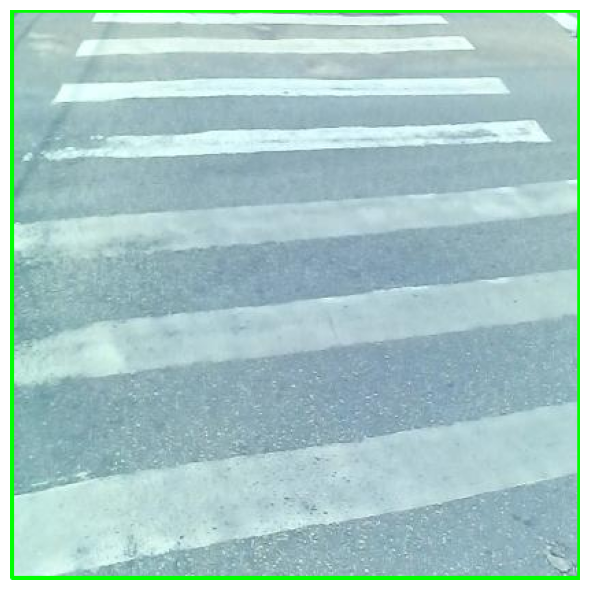

🟡 Testando imagem: i1045.jpg

image 1/1 C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\DetectObjects_JC\dataset\val\images\i1045.jpg: 640x640 1 Crosswalk, 312.4ms
Speed: 2.6ms preprocess, 312.4ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


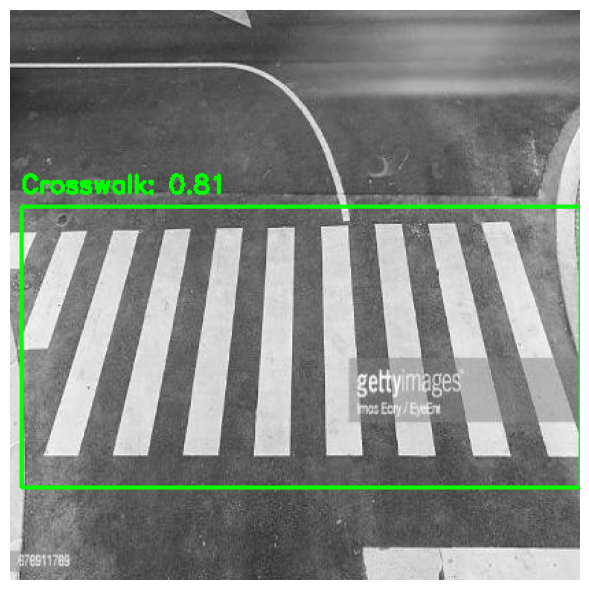

🟡 Testando imagem: i1051.jpg

image 1/1 C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\DetectObjects_JC\dataset\val\images\i1051.jpg: 640x640 1 Crosswalk Signal, 2 Crosswalks, 303.9ms
Speed: 2.8ms preprocess, 303.9ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


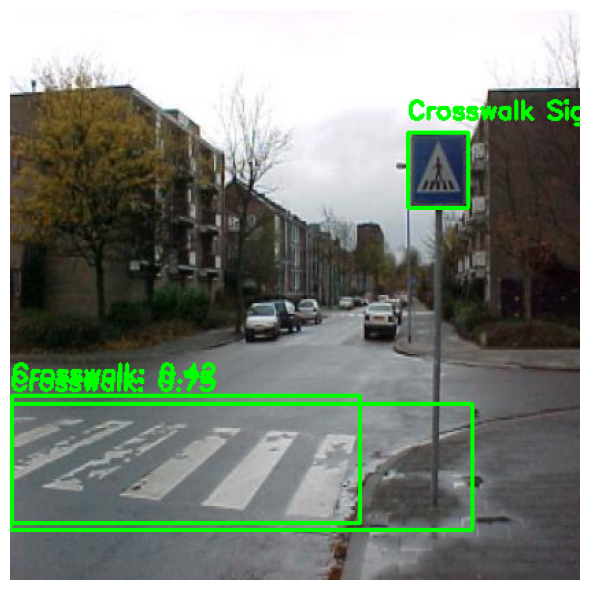

🟡 Testando imagem: i1055.jpg

image 1/1 C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\DetectObjects_JC\dataset\val\images\i1055.jpg: 640x640 1 Crosswalk, 304.1ms
Speed: 2.4ms preprocess, 304.1ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


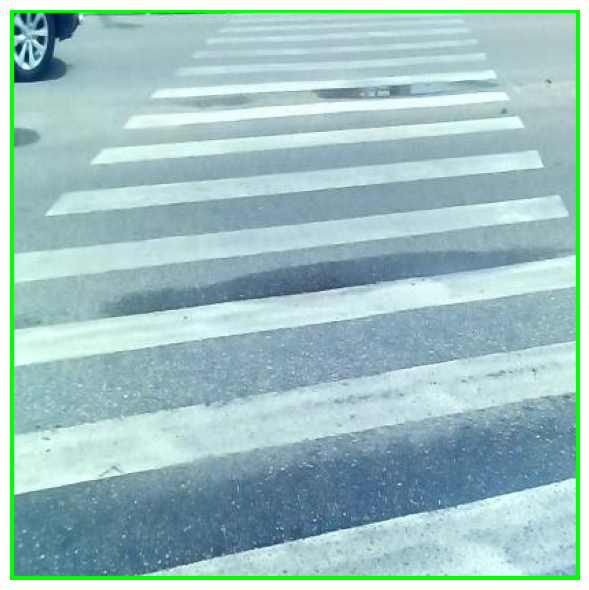

🟡 Testando imagem: i1069.jpg

image 1/1 C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\DetectObjects_JC\dataset\val\images\i1069.jpg: 640x640 2 Crosswalks, 306.8ms
Speed: 2.4ms preprocess, 306.8ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


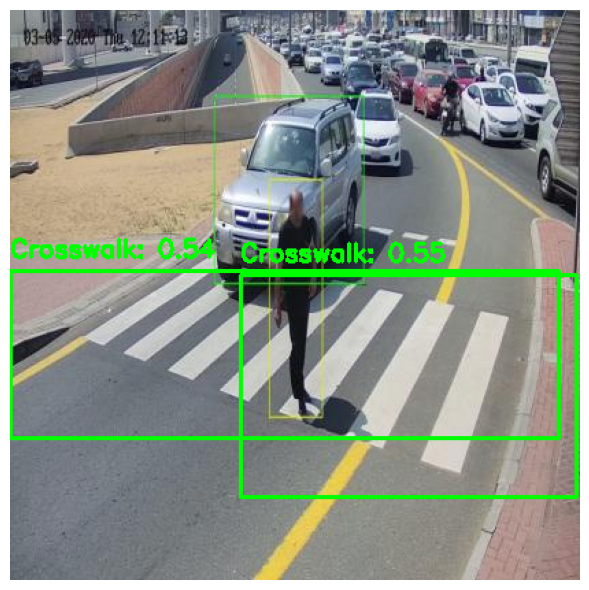

🟡 Testando imagem: i1270.jpg

image 1/1 C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\DetectObjects_JC\dataset\val\images\i1270.jpg: 384x640 4 Pedestrians, 14.6ms
Speed: 1.0ms preprocess, 14.6ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


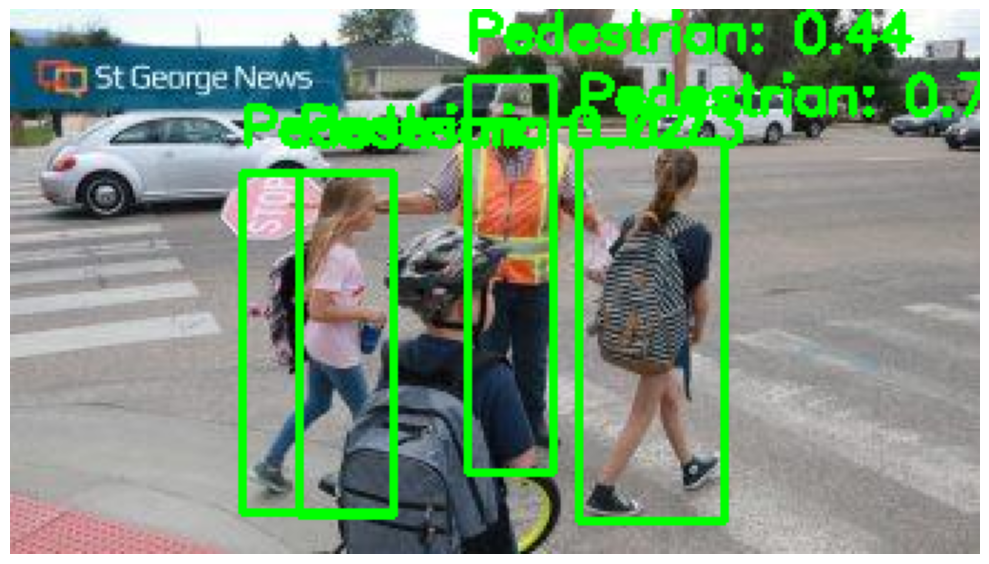

🟡 Testando imagem: i1271.jpg

image 1/1 C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\DetectObjects_JC\dataset\val\images\i1271.jpg: 448x640 1 Pedestrian, 17.0ms
Speed: 1.4ms preprocess, 17.0ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)


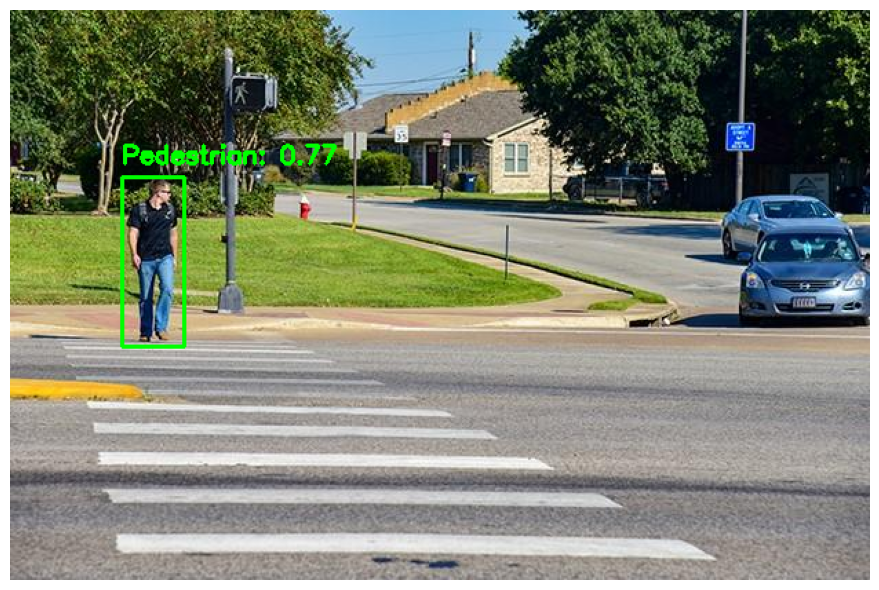

🟡 Testando imagem: i1272.jpg

image 1/1 C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\DetectObjects_JC\dataset\val\images\i1272.jpg: 288x640 2 Pedestrians, 12.7ms
Speed: 1.1ms preprocess, 12.7ms inference, 1.1ms postprocess per image at shape (1, 3, 288, 640)


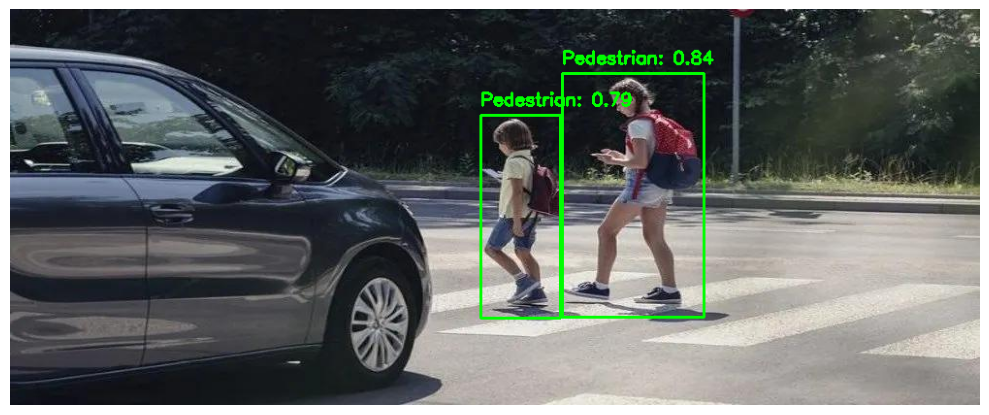

🟡 Testando imagem: i1273.jpg

image 1/1 C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\DetectObjects_JC\dataset\val\images\i1273.jpg: 480x640 6 Pedestrians, 35.4ms
Speed: 1.7ms preprocess, 35.4ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)


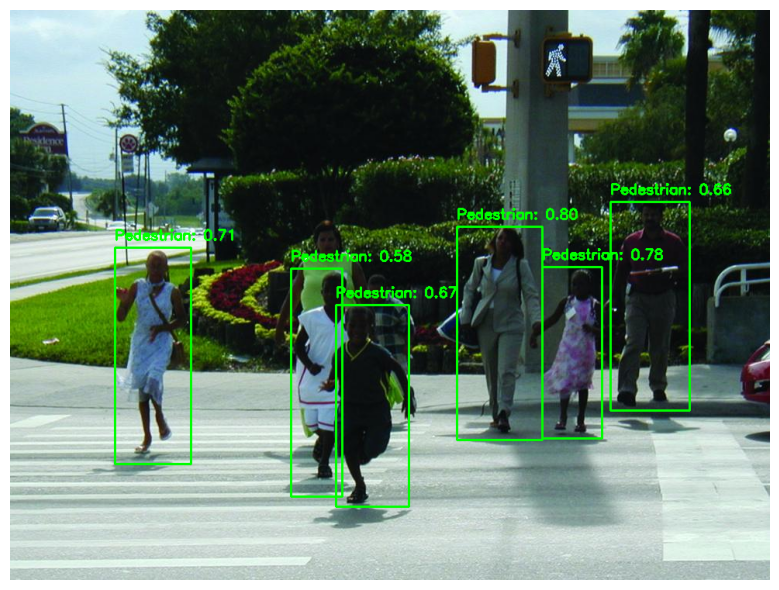

🟡 Testando imagem: i1274.jpg

image 1/1 C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\DetectObjects_JC\dataset\val\images\i1274.jpg: 448x640 4 Pedestrians, 16.9ms
Speed: 1.3ms preprocess, 16.9ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)


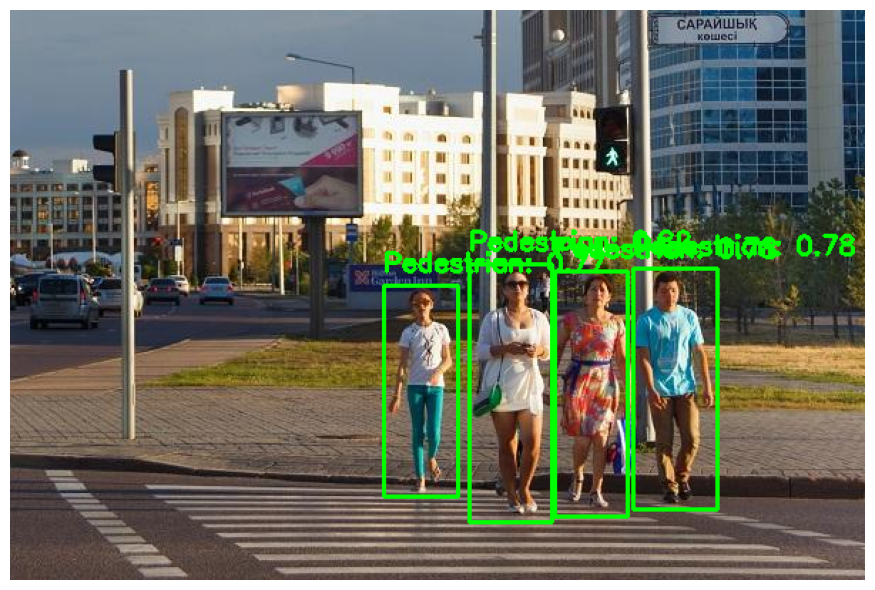

✅ Teste finalizado!


In [5]:
import os
import cv2
import torch
from PIL import Image
import matplotlib.pyplot as plt
from ultralytics import YOLO

# ✅ Para Jupyter Notebook
%matplotlib inline

# ✅ Modelo e classes
model_path = "runs_first_yolo/detect/yolo11m_finetuned/weights/best.pt"
val_img_dir = r"C:\Users\Jorge Cunha\Desktop\Python\AI_Detection_Cars\AAU2\DetectObjects_JC\dataset\val\images"

class_names = [
    "Trafic Light Signal", "Stop Signal", "Speedlimit Signal", "Crosswalk Signal",
    "Crosswalk", "Pedestrian", "Bus", "Car", "Truck"
]

model = YOLO(model_path)

# 🔍 Testar uma imagem
def test_image(image_path, model, class_names, confidence_threshold=0.6):
    results = model(image_path, conf=confidence_threshold)[0]
    image_cv = cv2.imread(image_path)

    for box, score, label in zip(results.boxes.xyxy, results.boxes.conf, results.boxes.cls):
        if score < confidence_threshold:
            continue
        x_min, y_min, x_max, y_max = map(int, box.tolist())
        label_idx = int(label)
        label_text = f"{class_names[label_idx]}: {score:.2f}"

        cv2.rectangle(image_cv, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
        cv2.putText(image_cv, label_text, (x_min, y_min - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # Mostra a imagem com detecções
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(image_cv, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.tight_layout()
    plt.show(block=True)  # Força exibição mesmo fora do Jupyter

# 🚀 Testar várias imagens
print("🖼️ Testando imagens...")
valid_images = sorted([
    f for f in os.listdir(val_img_dir)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
])

for img_name in valid_images[:10]:  # Altere para mais ou menos imagens
    img_path = os.path.join(val_img_dir, img_name)
    print(f"🟡 Testando imagem: {img_name}")
    test_image(img_path, model, class_names, confidence_threshold=0.4)

print("✅ Teste finalizado!")
